# **Predictive Model Evaluation**

## Objectives

* Extend notebook [09_predictive_modelling](/jupyter_notebooks/09_predictive_modelling.ipynb) to evaluate the fitted classification pipeline's performance
* Assess feature importance to understand model behaviour
* Revisit modelling choices and refit if performance does not meet requirements
* Answer Business Requirement 2: *TCS Hotels wants a machine learning model capable of predicting the likelihood of a booking cancellation, accessed through an operational dashboard that supports the reservations team in three ways: a risk report of upcoming arrivals, individual reservation search and a prospective booking risk assessor*

## Inputs

* Classification Pipeline "outputs/ml_pipeline/cancel_predict/v1/classification_model_pipeline.pkl"
* Train and test datasets from "outputs/ml_pipeline/preprocessing"

## Outputs

* Confusion matrix and classification report for train and test sets
* Feature importance plot
* Updated preprocessing pipeline saved to "outputs/ml_pipeline/cancel_predict/v2/classification_preprocessing_pipeline.pkl"
* Updated modelling pipeline saved to "outputs/ml_pipeline/cancel_predict/v2/classification_model_pipeline.pkl"
* Trained classification model for Business Requirement 2, to be integrated into the operational dashboard

## Additional Comments

* Feature importance analysis identified a potential data leakage risk in `deposit_type`. This was investigated and validated through an ablation study, resulting in its removal from the final (v2) pipeline. See the Feature Importance section for full reasoning.


---

# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect'

---

## Load Data

In [4]:
import pandas as pd
import joblib

X_train = pd.read_csv("outputs/ml_pipeline/preprocessing/X_train.csv")
X_test = pd.read_csv("outputs/ml_pipeline/preprocessing/X_test.csv")
y_train = pd.read_csv("outputs/ml_pipeline/preprocessing/y_train.csv").squeeze()
y_test = pd.read_csv("outputs/ml_pipeline/preprocessing/y_test.csv").squeeze()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


(95344, 29) (95344,) (23836, 29) (23836,)


* Load the fitted pipeline

In [5]:
classification_model_pipeline = joblib.load(
    "outputs/ml_pipeline/cancel_predict/v1/classification_model_pipeline.pkl"
)
classification_model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('DropFeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute 

---

## Generate Predictions

In [6]:
y_train_pred = classification_model_pipeline.predict(X_train)
y_test_pred = classification_model_pipeline.predict(X_test)

---

## Confusion Matrix

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="winter",
                xticklabels=["Not Cancelled", "Cancelled"],
                yticklabels=["Not Cancelled", "Cancelled"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()


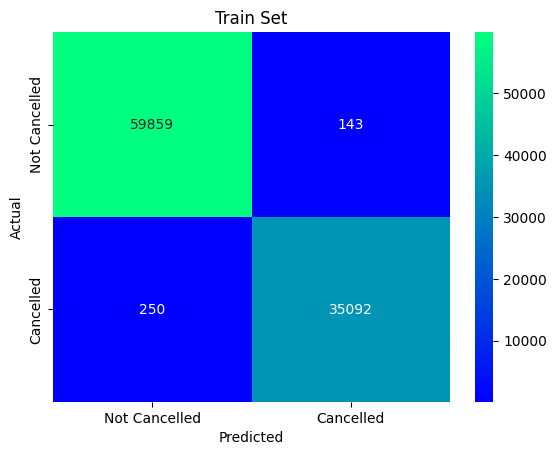

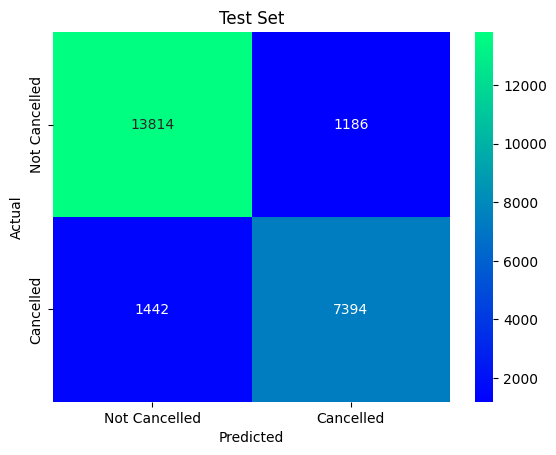

In [9]:
plot_confusion_matrix(y_train, y_train_pred, "Train Set")
plot_confusion_matrix(y_test, y_test_pred, "Test Set")

* It appears as though there are more errors generated on the test set suggesting some overfitting

---

## Classification Report

In [10]:
from sklearn.metrics import classification_report

print("TRAIN SET\n")
print(classification_report(y_train, y_train_pred, target_names=["Not Cancelled", "Cancelled"]))

print("TEST SET\n")
print(classification_report(y_test, y_test_pred, target_names=["Not Cancelled", "Cancelled"]))

TRAIN SET

               precision    recall  f1-score   support

Not Cancelled       1.00      1.00      1.00     60002
    Cancelled       1.00      0.99      0.99     35342

     accuracy                           1.00     95344
    macro avg       1.00      1.00      1.00     95344
 weighted avg       1.00      1.00      1.00     95344

TEST SET

               precision    recall  f1-score   support

Not Cancelled       0.91      0.92      0.91     15000
    Cancelled       0.86      0.84      0.85      8836

     accuracy                           0.89     23836
    macro avg       0.88      0.88      0.88     23836
 weighted avg       0.89      0.89      0.89     23836



* This test confirms overfitting of the model, displaying near perfect scores on all metrics on the train set.
* The model is still hitting the target recall value of 0.8, but given the .15 difference in recall between the 2 sets, revisiting the hyperparameters is appropriate.

---

## Extra Tuning to Reduce Overfitting

* Copy over the unfit pipeline and hyperparameter function from the [predictive modelling](/jupyter_notebooks/09_predictive_modelling.ipynb) notebook

In [14]:
classification_model_preprocessing_pipeline = joblib.load("outputs/ml_pipeline/preprocessing/classification_preprocessing_pipeline.pkl")

In [15]:
from sklearn.pipeline import Pipeline
from utils.custom_transformers import undefined_meal

def classification_pipeline(model):
    pipeline_base = Pipeline([
        ("Preprocessing", classification_model_preprocessing_pipeline),
        ("model", model)
    ])

    return pipeline_base

In [16]:
# Update to test for overfitting rather than pure recall scores

from sklearn.base import clone
from sklearn.model_selection import cross_validate

def parameter_comparison(model, param, values):

    results = []

    for value in values:

        current_model = clone(model)
        current_model.set_params(**{param: value})

        scores = cross_validate(
            classification_pipeline(current_model),
            X_train,
            y_train.values.ravel(),
            scoring="recall",
            cv=5,
            return_train_score=True,
            verbose=1
        )

        results.append({
            "parameter": param,
            "value": value,
            "train_recall": scores["train_score"].mean(),
            "val_recall": scores["test_score"].mean(),
            "diff": scores["train_score"].mean() - scores["test_score"].mean()
        })

    return pd.DataFrame(results)

* I suspect that the increased tree depth is largely responsible for the overfitting, I will keep the carried forward n_estimators and retest max_depth to retrieve more information

In [19]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=0, n_estimators=500)

max_depth_results = parameter_comparison(
    model=model,
    param="max_depth",
    values=[6, 8, 10]
)

max_depth_results

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.3min finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.5min finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.9min finished


,parameter,value,train_recall,val_recall,diff
0,max_depth,6,0.937553,0.825901,0.111652
1,max_depth,8,0.988972,0.830372,0.158600
2,max_depth,10,0.993867,0.828844,0.165023


* This shows that the smallest gap between training and validation is when max_depthe is set to the default value of 6
* Now to also re-test the n_estimators values using the default max_depth value

In [20]:
model = XGBClassifier(random_state=0)

n_estimators_results = parameter_comparison(
    model=model,
    param="n_estimators",
    values=[100, 200, 500]
)

n_estimators_results

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   34.1s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   49.6s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.3min finished


,parameter,value,train_recall,val_recall,diff
0,n_estimators,100,0.831405,0.802218,0.029186
1,n_estimators,200,0.872687,0.814611,0.058075
2,n_estimators,500,0.937553,0.825901,0.111652


* From this test we can see that the gap between variance increases with estimators. Rather than reducing estimators, I will try other parameters that help to reduce overfitting to see if there is improvement to be had there.

In [23]:
model = XGBClassifier(random_state=0, n_estimators=500)

min_child_weight_results = parameter_comparison(
    model=model,
    param="min_child_weight",
    values=[1, 5, 10, 20, 50]
)

min_child_weight_results

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.0min finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   59.9s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   59.6s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   58.5s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   56.6s finished


,parameter,value,train_recall,val_recall,diff
0,min_child_weight,1,0.937553,0.825901,0.111652
1,min_child_weight,5,0.915023,0.822760,0.092263
2,min_child_weight,10,0.899829,0.819676,0.080153
3,min_child_weight,20,0.880008,0.817130,0.062878
4,min_child_weight,50,0.855703,0.810622,0.045081


* min_child_weight of 10 reduced the variance by 3 points without significantly damaging recall so will be carried forward

In [24]:
model = XGBClassifier(random_state=0, n_estimators=500, min_child_weight=10)

gamma_results = parameter_comparison(
    model=model,
    param="gamma",
    values=[0, 0.1, 0.5, 1, 5]
)

gamma_results

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.3min finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   49.4s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   52.9s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   45.9s finished


,parameter,value,train_recall,val_recall,diff
0,gamma,0.0,0.899829,0.819676,0.080153
1,gamma,0.1,0.878219,0.816847,0.061372
2,gamma,0.5,0.827252,0.801709,0.025543
3,gamma,1.0,0.815015,0.795795,0.019219
4,gamma,5.0,0.783438,0.776102,0.007336


* The gamma value of 0.1 has reduced variance by a further 2 points without significant impact on the recall score.

### Update the pipeline and repeat classification report with the updated hyperparameters

In [43]:
def classification_pipeline():
    pipeline_base = Pipeline([
        ("Preprocessing", classification_model_preprocessing_pipeline),
        ("model", XGBClassifier(random_state=0, n_estimators=500, min_child_weight=10, gamma=0.1))
    ])

    return pipeline_base

* Fit to training data

In [26]:
X = X_train.copy()
y = y_train.copy()

updated_classification_model_pipeline = classification_pipeline()
updated_classification_model_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('DropFeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute 

In [27]:
y_train_pred = updated_classification_model_pipeline.predict(X_train)
y_test_pred = updated_classification_model_pipeline.predict(X_test)

In [28]:
print("TRAIN SET\n")
print(classification_report(y_train, y_train_pred, target_names=["Not Cancelled", "Cancelled"]))

print("TEST SET\n")
print(classification_report(y_test, y_test_pred, target_names=["Not Cancelled", "Cancelled"]))

TRAIN SET

               precision    recall  f1-score   support

Not Cancelled       0.93      0.95      0.94     60002
    Cancelled       0.91      0.88      0.89     35342

     accuracy                           0.92     95344
    macro avg       0.92      0.91      0.91     95344
 weighted avg       0.92      0.92      0.92     95344

TEST SET

               precision    recall  f1-score   support

Not Cancelled       0.90      0.92      0.91     15000
    Cancelled       0.86      0.82      0.84      8836

     accuracy                           0.88     23836
    macro avg       0.88      0.87      0.87     23836
 weighted avg       0.88      0.88      0.88     23836



* Repeat confusion matrix

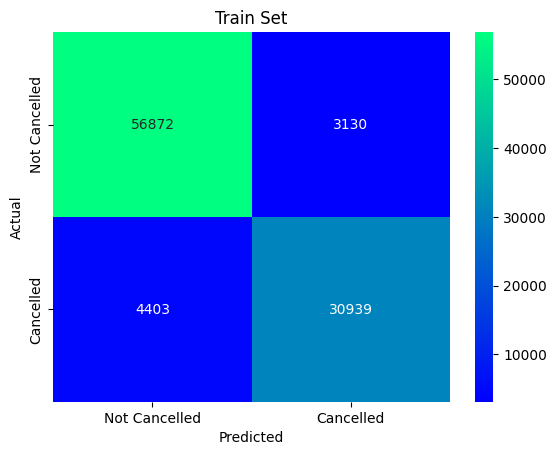

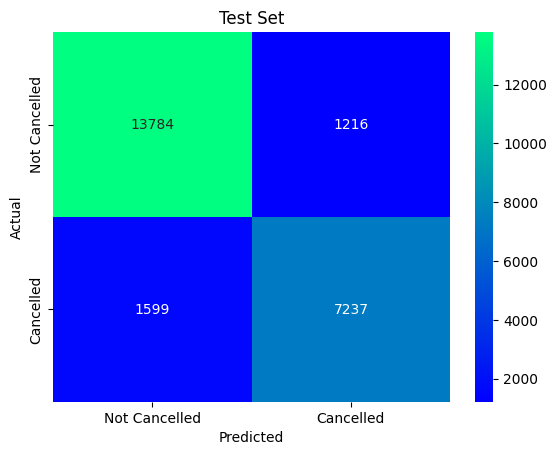

In [29]:
plot_confusion_matrix(y_train, y_train_pred, "Train Set")
plot_confusion_matrix(y_test, y_test_pred, "Test Set")

In [31]:
from sklearn.metrics import recall_score

train_recall = recall_score(y_train, y_train_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)

target_recall = 0.80

print(f"Train recall: {train_recall:.2f}")
print(f"Test recall: {test_recall:.2f}")
print(f"Target recall met on test set: {test_recall >= target_recall}")

Train recall: 0.88
Test recall: 0.82
Target recall met on test set: True


* The retuned model reduced the train/test recall gap from 15.6 to 6.0 points, indicating substantially less overfitting, while test recall of 0.82 continues to exceed the 0.80 business target, albeit with a narrower margin than the original model (0.84)

---

## Feature Importance

In [32]:
preprocessed_sample = classification_model_pipeline.named_steps["Preprocessing"].transform(X_train)
feature_names = preprocessed_sample.columns

model = classification_model_pipeline.named_steps["model"]
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)


,Feature,Importance
49,deposit_type_Non Refund,0.868952
15,required_car_parking_spaces,0.064179
9,previous_cancellations,0.009858
25,market_segment_Online TA,0.007938
52,customer_type_Transient,0.002966
48,deposit_type_No Deposit,0.002924
47,assigned_room_type_I,0.001990
26,market_segment_Direct,0.001805
16,total_of_special_requests,0.001706
13,days_in_waiting_list,0.001600


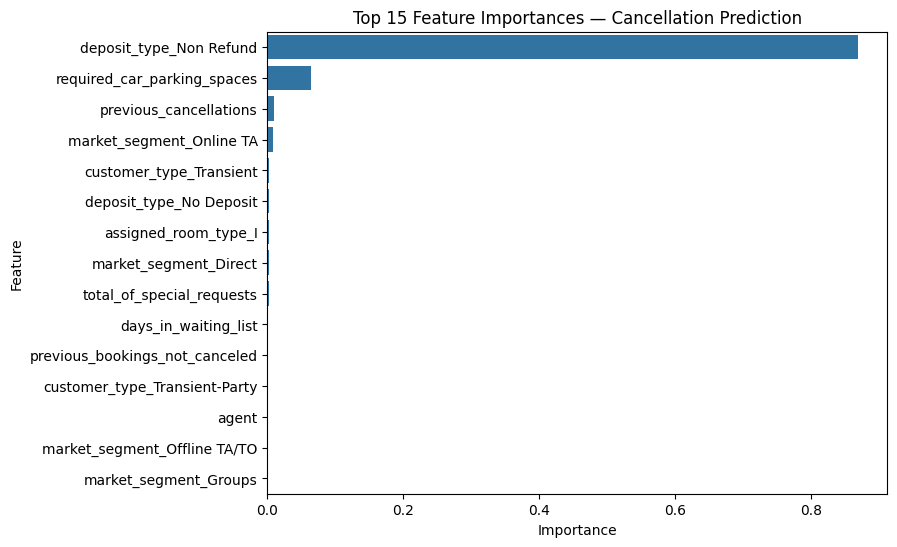

In [33]:
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances — Cancellation Prediction")
plt.show()

* deposit_type_Non_Refund is dominating the feature importance to such an extent as to raise questions bout whether it is a genuine deposit or some other mechanism such as full payment taken at the point of cancellation which could be causing data leakage.

* Test model performace without `deposit_type`

In [50]:
from feature_engine.selection import DropFeatures
from feature_engine.imputation import ArbitraryNumberImputer, CategoricalImputer
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OneHotEncoder, RareLabelEncoder, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer

def classification_pipeline_no_deposit():
    pipeline_base = Pipeline([
        ("DropFeatures", DropFeatures(features_to_drop=["company", "arrival_date_year", "deposit_type", "arrival_date_week_number"])),
        ("FunctionTransformer", FunctionTransformer(undefined_meal)),
        ("ArbitraryNumberImputer", ArbitraryNumberImputer(arbitrary_number=0, variables="agent")),
        ("CategoricalImputer", CategoricalImputer(imputation_method="frequent", variables="country")),
        ("Winsorizer", Winsorizer(capping_method="iqr", tail="right", fold=1.5, variables=["lead_time", "adr",
                                                                                           "stays_in_weekend_nights", "stays_in_week_nights"])),
        ("RareLabelEncoder", RareLabelEncoder(tol=0.01, variables="country")),
        ("OrdinalEncoder", OrdinalEncoder(encoding_method="arbitrary", variables="country", ignore_format=True)),
        ("MonthEncoder", OneHotEncoder(variables="arrival_date_month")) ,
        ("OneHotEncoder", OneHotEncoder(variables=["hotel", "meal", "market_segment", "distribution_channel",
                                                   "reserved_room_type", "assigned_room_type", "customer_type"], drop_last=True)),
        ("model", XGBClassifier(random_state=0, n_estimators=500, min_child_weight=10, gamma=0.1))
    ])

    return pipeline_base

In [52]:
X_train_no_deposit = X_train.copy()
X_test_no_deposit = X_test.copy()

classification_model_pipeline_no_deposit = classification_pipeline_no_deposit()
classification_model_pipeline_no_deposit.fit(X_train_no_deposit, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('DropFeatures', ...), ('FunctionTransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,features_to_drop,"['company', 'arrival_date_year', ...]"
Name,Type,Value
feature_names_in_,list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"


In [53]:
y_train_pred_no_deposit = classification_model_pipeline_no_deposit.predict(X_train)
y_test_pred_no_deposit = classification_model_pipeline_no_deposit.predict(X_test)

In [54]:
print("TRAIN SET\n")
print(classification_report(y_train, y_train_pred_no_deposit, target_names=["Not Cancelled", "Cancelled"]))

print("TEST SET\n")
print(classification_report(y_test, y_test_pred_no_deposit, target_names=["Not Cancelled", "Cancelled"]))

TRAIN SET

               precision    recall  f1-score   support

Not Cancelled       0.93      0.95      0.94     60002
    Cancelled       0.91      0.87      0.89     35342

     accuracy                           0.92     95344
    macro avg       0.92      0.91      0.91     95344
 weighted avg       0.92      0.92      0.92     95344

TEST SET

               precision    recall  f1-score   support

Not Cancelled       0.90      0.92      0.91     15000
    Cancelled       0.85      0.82      0.83      8836

     accuracy                           0.88     23836
    macro avg       0.87      0.87      0.87     23836
 weighted avg       0.88      0.88      0.88     23836



* Feature importance identified deposit_type as the dominant predictor. However, an ablation study in which the feature was removed showed virtually no degradation in model performance, indicating that the predictive information contained in deposit_type is largely captured by other variables.

| Metric (Cancelled class) | With deposit_type | Without deposit_type | Difference |
| --- | --- | --- | --- |
| Precision | 0.86 | 0.85 | -0.01 |
| Recall | 0.82 | 0.82 | 0.00 |
| F1-score | 0.84 | 0.83 | -0.01 |
| Accuracy | 0.88 | 0.88 | 0.00 |


* Run a comparison feature importance

In [56]:
sample_preprocessed = classification_model_pipeline_no_deposit[:-1].transform(X_train)
feature_names = sample_preprocessed.columns

model = classification_model_pipeline_no_deposit.named_steps["model"]
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
15,required_car_parking_spaces,0.231206
37,market_segment_Online TA,0.123860
9,previous_cancellations,0.091904
60,customer_type_Transient-Party,0.041201
33,market_segment_Groups,0.039863
16,total_of_special_requests,0.039733
62,customer_type_Transient,0.033637
7,country,0.031836
42,reserved_room_type_A,0.031771
59,assigned_room_type_I,0.021365


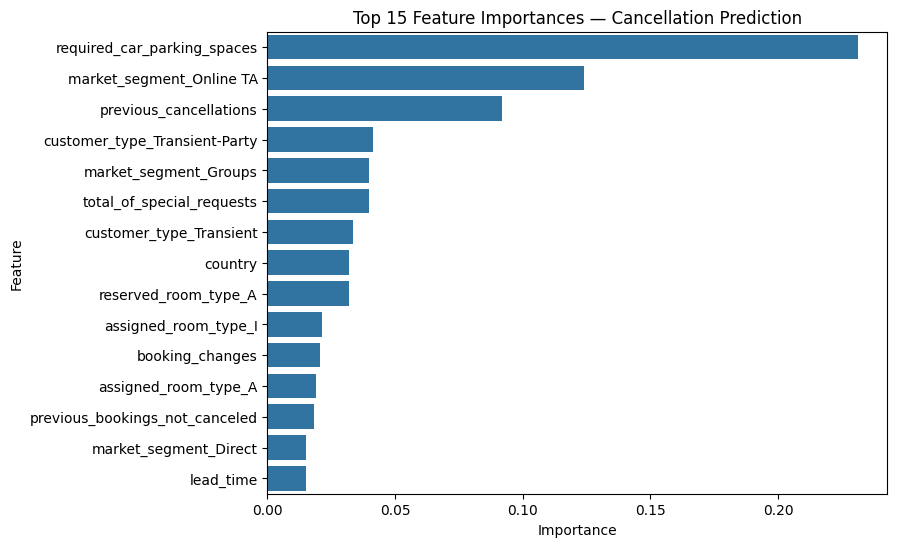

In [57]:
plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances — Cancellation Prediction")
plt.show()

In [59]:
from sklearn.model_selection import cross_validate

results = {}
pipelines = {
    "with_deposit": updated_classification_model_pipeline,
    "without_deposit": classification_model_pipeline_no_deposit
}

for name, pipeline in pipelines.items():

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='f1',
        return_train_score=False,
        n_jobs=-1
    )

    results[name] = {
        "Mean CV F1": cv_results["test_score"].mean(),
        "CV Std F1": cv_results["test_score"].std(),
        "Individual Scores": cv_results["test_score"]
    }


cv_comparison = pd.DataFrame(results).T
cv_comparison

,Mean CV F1,CV Std F1,Individual Scores
with_deposit,0.834971,0.003654,"[0.8394689630426982, 0.8293001962066711, 0.836..."
without_deposit,0.834549,0.003675,"[0.839233144252172, 0.8279764927809621, 0.8360..."


* The F1 score comparison confirms that there is insignificant impact on the results to warrant keeping the deposit_type feature
* There is ambiguity in how the variable is derived leading to concerns that there could be data-leakage: 

>Value calculated based on the payments identified for the booking in the transaction (TR) table before the booking׳s arrival or cancellation date. <br>
>Non Refund – a deposit was made in the value of the total stay cost; [*Hotel booking demand datasets*](https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/)

* Although it was the most influential feature in the initial model (accounting for 87% of feature importance), its calculation relies on transaction information recorded before the booking’s arrival or cancellation date, raising uncertainty around whether this information would be available at the point of prediction. 
* In addition, the strong association between the Non Refund category and cancellations suggests that the feature may act as a proxy for the target rather than capturing independent predictive behaviour. 
* Ablation testing showed that removing `deposit_type` resulted in only a marginal reduction in model performance (~1% decrease in F1 score and precision), while producing a more balanced feature importance distribution and a more robust, interpretable model. 
* Therefore, `deposit_type` will be removed from the final model to reduce leakage risk or model over-reliance without materially impacting predictive performance.

* Update the preprocessing pipelines to reflect the removal of `deposit_type`

In [62]:
outlier_cols = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights"]
categorical_cols = ["hotel", "meal", "market_segment", "distribution_channel", "reserved_room_type", "assigned_room_type", "customer_type"]

def preprocessing():

    pipeline_base = Pipeline([
        ("DropFeatures", DropFeatures(features_to_drop=["company", "arrival_date_year", "deposit_type", "arrival_date_week_number"])),
        ("FunctionTransformer", FunctionTransformer(undefined_meal)),
        ("ArbitraryNumberImputer", ArbitraryNumberImputer(arbitrary_number=0, variables="agent")),
        ("CategoricalImputer", CategoricalImputer(imputation_method="frequent", variables="country")),
        ("Winsorizer", Winsorizer(capping_method="iqr", tail="right", fold=1.5, variables=outlier_cols)),
        ("RareLabelEncoder", RareLabelEncoder(tol=0.01, variables="country")),
        ("OrdinalEncoder", OrdinalEncoder(encoding_method="arbitrary", variables="country", ignore_format=True)),
        ("MonthEncoder", OneHotEncoder(variables="arrival_date_month")), 
        ("OneHotEncoder", OneHotEncoder(variables=categorical_cols, drop_last=True))
    ])

    return pipeline_base

preprocessing_pipeline = preprocessing()

In [63]:
def prediction():

    pipeline_base = Pipeline([
        ("Preprcessing", preprocessing_pipeline),
        ("model", XGBClassifier(random_state=0, n_estimators=500, min_child_weight=10, gamma=0.1))
    ])

    return pipeline_base

prediction_pipeline = prediction()

In [64]:
X = X_train.copy()
y = y_train.copy()

prediction_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprcessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['hotel', 'le...me', 'ar...ar', 'ar...th', ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('DropFeatures', ...), ('FunctionTransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attri

In [66]:
y_train_pred_final = prediction_pipeline.predict(X_train)
y_test_pred_final = prediction_pipeline.predict(X_test)

print("TRAIN SET\n")
print(classification_report(y_train, y_train_pred_final, target_names=["Not Cancelled", "Cancelled"]))
print("TEST SET\n")
print(classification_report(y_test, y_test_pred_final, target_names=["Not Cancelled", "Cancelled"]))

TRAIN SET

               precision    recall  f1-score   support

Not Cancelled       0.93      0.95      0.94     60002
    Cancelled       0.91      0.87      0.89     35342

     accuracy                           0.92     95344
    macro avg       0.92      0.91      0.91     95344
 weighted avg       0.92      0.92      0.92     95344

TEST SET

               precision    recall  f1-score   support

Not Cancelled       0.90      0.92      0.91     15000
    Cancelled       0.85      0.82      0.83      8836

     accuracy                           0.88     23836
    macro avg       0.87      0.87      0.87     23836
 weighted avg       0.88      0.88      0.88     23836



---

## Conclusions

**Overfitting**
* Initial evaluation of the v1 pipeline showed a substantial train/test recall gap (15.6 point difference) combined with near perfect train set scores (1.00 or 0.99 across all metrics). This suggested the model was overfitting to the training data despite meeting the 0.80 recall target on the test set. 
* Targeted hyperparameter tuning — reducing `max_depth` to its default, increasing `min_child_weight` to 10, and adding `gamma=0.1` — reduced this gap to 6.0 points (train 0.88, test 0.82) with only marginal cost to test recall, producing a model with a more realistic generalisation profile.

**Feature Importance**
* Feature importance analysis of the retuned model showed `deposit_type_Non_Refund` accounting for approximately 87% of total importance, far exceeding any other feature. 
* The deposit type "Non Refund" had a cancellation rate of 99% as discovered in the [cancellation eda](/jupyter_notebooks/02_cancellation_eda.ipynb) notebook and combined with the feature's high importance in the model, this raised a concern that this feature could be acting as a proxy for `is_canceled`rather than an independent predictor
* Investigation of the feature's derivation raised a data leakage concern: it is calculated from transaction records that may only be finalised at or near the point of cancellation, meaning it could encode information not genuinely available at prediction time. 
* An ablation study confirmed the feature was not essential to model performance — removing it produced a negligible drop in F1, precision, and recall (≤0.01 across all three) — while yielding a more balanced feature importance distribution across the remaining predictors. 
* `deposit_type` was therefore removed from the final pipeline (v2) to reduce leakage risk and produce a more interpretable, robust model without a meaningful performance cost.

**Business Requirement 2**
* The final v2 pipeline achieves a test recall of 0.82 for the Cancelled class, exceeding the 0.80 target defined in the ML Business Case. Combined with the reduced overfitting gap and removal of a feature carrying leakage risk, the model is considered fit for integration into the operational dashboard to answer Business Requirement 2.

**Limitations and Next Steps**
* The remaining ~6 point train/test gap suggests some overfitting persists; further regularisation (`reg_alpha`/`reg_lambda`) could be explored in a future iteration if time allows.
* `deposit_type`'s removal was justified via ablation on this dataset only; if the feature's true derivation timing can be confirmed with the data provider, its reinstatement could be reconsidered.

---

## Save Files

In [65]:
import os
try:
  os.makedirs(name='outputs/ml_pipeline/cancel_predict/v2')
except Exception as e:
  print(e)


* Save updated preprocessing pipeline

In [67]:
joblib.dump(value=preprocessing_pipeline, filename="outputs/ml_pipeline/cancel_predict/v2/classification_preprocessing_pipeline.pkl")

['outputs/ml_pipeline/cancel_predict/v2/classification_preprocessing_pipeline.pkl']

* Save the updated prediction pipeline

In [68]:
joblib.dump(value=prediction_pipeline, filename="outputs/ml_pipeline/cancel_predict/v2/classification_model_pipeline.pkl")

['outputs/ml_pipeline/cancel_predict/v2/classification_model_pipeline.pkl']